In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pickle

In [4]:
df = pd.read_csv("../data/netflix_milestone2.csv")
df.shape

(8807, 19)

In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genre_list,country_list,year_added,rating_binary,rating_category,Content_Length_Category,Original_vs_Licensed
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,PG-13,90 min,documentaries,"As her father nears the end of his life, filmm...",['documentaries'],['united states'],2021.0,0,General,Medium Movie,Licensed
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,TV-MA,2 Seasons,"international tv shows, tv dramas, tv mysteries","After crossing paths at a party, a Cape Town t...","['international tv shows', 'tv dramas', 'tv my...",['south africa'],2021.0,1,Adult,Multi-Season Show,Licensed
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"crime tv shows, international tv shows, tv act...",To protect his family from a powerful drug lor...,"['crime tv shows', 'international tv shows', '...",['unknown'],2021.0,1,Adult,Single Season Show,Licensed
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,unknown,2021-09-24,2021,TV-MA,1 Season,"docuseries, reality tv","Feuds, flirtations and toilet talk go down amo...","['docuseries', 'reality tv']",['unknown'],2021.0,1,Adult,Single Season Show,Licensed
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,TV-MA,2 Seasons,"international tv shows, romantic tv shows, tv ...",In a city of coaching centers known to train I...,"['international tv shows', 'romantic tv shows'...",['india'],2021.0,1,Adult,Multi-Season Show,Licensed


In [6]:
df_model = df.copy()

In [7]:
rating_encoder = LabelEncoder()

df_model["rating_encoded"] = rating_encoder.fit_transform(df_model["rating"])

df_model.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genre_list,country_list,year_added,rating_binary,rating_category,Content_Length_Category,Original_vs_Licensed,rating_encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,PG-13,90 min,documentaries,"As her father nears the end of his life, filmm...",['documentaries'],['united states'],2021.0,0,General,Medium Movie,Licensed,5
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,TV-MA,2 Seasons,"international tv shows, tv dramas, tv mysteries","After crossing paths at a party, a Cape Town t...","['international tv shows', 'tv dramas', 'tv my...",['south africa'],2021.0,1,Adult,Multi-Season Show,Licensed,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"crime tv shows, international tv shows, tv act...",To protect his family from a powerful drug lor...,"['crime tv shows', 'international tv shows', '...",['unknown'],2021.0,1,Adult,Single Season Show,Licensed,9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,unknown,2021-09-24,2021,TV-MA,1 Season,"docuseries, reality tv","Feuds, flirtations and toilet talk go down amo...","['docuseries', 'reality tv']",['unknown'],2021.0,1,Adult,Single Season Show,Licensed,9
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,TV-MA,2 Seasons,"international tv shows, romantic tv shows, tv ...",In a city of coaching centers known to train I...,"['international tv shows', 'romantic tv shows'...",['india'],2021.0,1,Adult,Multi-Season Show,Licensed,9


In [8]:
length_encoder = LabelEncoder()

df_model["length_encoded"] = length_encoder.fit_transform(
    df_model["Content_Length_Category"]
)

In [9]:
type_encoder = LabelEncoder()

df_model["type_encoded"] = type_encoder.fit_transform(df_model["type"])

In [10]:
def convert_duration(duration):
    
    if isinstance(duration, str):
        
        if "min" in duration:
            return int(duration.split()[0])
        
        elif "Season" in duration:
            return int(duration.split()[0]) * 60
    
    return np.nan


df_model["duration_numeric"] = df_model["duration"].apply(convert_duration)

In [11]:
df_model["duration_numeric"] = df_model["duration_numeric"].fillna(
    df_model["duration_numeric"].median()
)

In [12]:
cluster_features = df_model[
    ["rating_encoded", "duration_numeric", "length_encoded"]
]

In [13]:
kmeans = KMeans(n_clusters=4, random_state=42)

df_model["cluster"] = kmeans.fit_predict(cluster_features)

df_model["cluster"].value_counts()
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genre_list,country_list,year_added,rating_binary,rating_category,Content_Length_Category,Original_vs_Licensed
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,PG-13,90 min,documentaries,"As her father nears the end of his life, filmm...",['documentaries'],['united states'],2021.0,0,General,Medium Movie,Licensed
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,TV-MA,2 Seasons,"international tv shows, tv dramas, tv mysteries","After crossing paths at a party, a Cape Town t...","['international tv shows', 'tv dramas', 'tv my...",['south africa'],2021.0,1,Adult,Multi-Season Show,Licensed
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"crime tv shows, international tv shows, tv act...",To protect his family from a powerful drug lor...,"['crime tv shows', 'international tv shows', '...",['unknown'],2021.0,1,Adult,Single Season Show,Licensed
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,unknown,2021-09-24,2021,TV-MA,1 Season,"docuseries, reality tv","Feuds, flirtations and toilet talk go down amo...","['docuseries', 'reality tv']",['unknown'],2021.0,1,Adult,Single Season Show,Licensed
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,TV-MA,2 Seasons,"international tv shows, romantic tv shows, tv ...",In a city of coaching centers known to train I...,"['international tv shows', 'romantic tv shows'...",['india'],2021.0,1,Adult,Multi-Season Show,Licensed


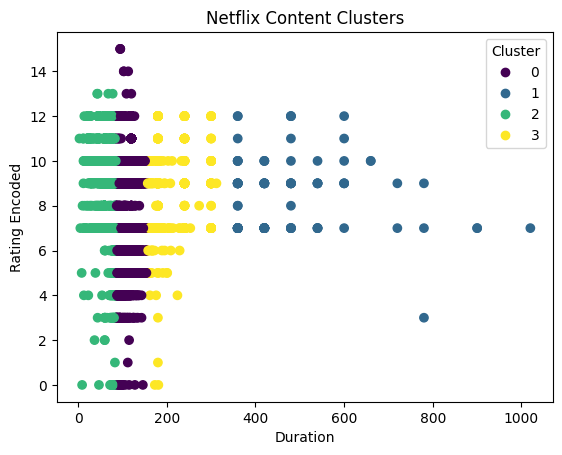

In [15]:
plt.figure()

scatter = plt.scatter(
    df_model["duration_numeric"],
    df_model["rating_encoded"],
    c=df_model["cluster"],
    cmap="viridis"
)

plt.xlabel("Duration")
plt.ylabel("Rating Encoded")
plt.title("Netflix Content Clusters")

# Create legend for clusters
handles, labels = scatter.legend_elements()

plt.legend(handles, labels, title="Cluster")

plt.show()

In [16]:
rating_cat_encoder = LabelEncoder()

df_model["rating_category_encoded"] = rating_cat_encoder.fit_transform(
    df_model["rating_category"]
)

In [17]:
features = [
    "rating_encoded",
    "duration_numeric",
    "length_encoded",
    "rating_category_encoded"
]

X = df_model[features]

y = df_model["type_encoded"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [21]:
y_pred = model.predict(X_test)

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1214
           1       1.00      1.00      1.00       548

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



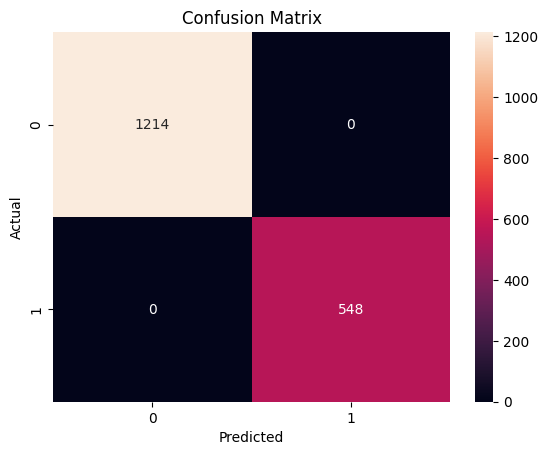

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
importance = model.feature_importances_

feature_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

feature_df

,Feature,Importance
2,length_encoded,0.649742
1,duration_numeric,0.331238
0,rating_encoded,0.018976
3,rating_category_encoded,0.000044


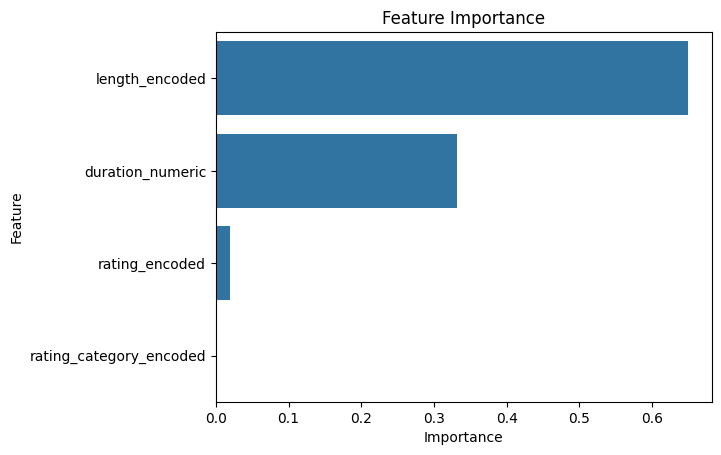

In [25]:
plt.figure()

sns.barplot(
    data=feature_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [27]:
with open("../models/netflix_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [28]:
df_model.to_csv("../data/netflix_milestone3.csv", index=False)